## Modeling for predicting 72h ED revisit at ED discharge

Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [6]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve, get_lstm_data_gen
from dataset_path import output_path

df_train = pd.read_csv('mv_train_DISPOSITION.csv')
df_test = pd.read_csv('mv_test_DISPOSITION.csv')
df_val = pd.read_csv('mv_val_DISPOSITION.csv')
confidence_interval = 95
random_seed = 0

In [7]:
random.seed(random_seed)
np.random.seed(random_seed)

In [8]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 
df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,228428,10870475,24160860.0,32267643,2118-02-13 23:54:00,2118-02-14 15:44:00,47,F,2118,NaN,2118-02-14 04:18:00,2118-02-14 15:44:00,NaN,WHITE,2118-02-13 23:54:00,2118-02-14 15:44:00,Other,2118,47,False,False,False,0 days 15:50:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,15.83,NaN,NaN,36.712811,85.085489,17.554838,98.374259,134.906695,77.480026,4.167576,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,37.555556,84.0,18.0,97.0,114.0,74.0,5.0,8.0,0.0,96.622249,0,0,2,0,0,1,train,examination hand pa lat and oblique left indic...,['files/p1087/p10870475/s46566754/46566754']
1,7166,11258835,NaN,31208360,2175-04-18 13:54:00,2175-04-18 13:55:00,77,F,2175,NaN,NaN,NaN,NaN,WHITE,NaN,NaN,NaN,2175,77,False,False,False,0 days 00:01:00,NaN,NaN,False,False,False,0,0,0,2176-04-08 17:38:00,356 days 03:43:00,False,0,0,0,0,0,0,0.02,NaN,356.15,36.444444,73.000000,18.000000,96.000000,187.000000,97.000000,5.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.333333,73.0,18.0,97.0,145.0,93.0,0.0,5.0,12.0,127.000000,3,9,8,0,0,1,train,history screening comparison hologic digital s...,['files/p1125/p11258835/s41234765/41234765']
2,163449,19301404,NaN,37156637,2123-06-05 16:49:00,2123-06-05 17:20:00,20,F,2123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2123,20,False,False,False,0 days 00:31:00,NaN,NaN,False,False,False,1,1,1,2123-09-01 17:19:00,87 days 23:59:00,False,0,0,0,0,0,0,0.52,NaN,88.00,35.944444,89.000000,18.000000,100.000000,144.000000,87.000000,8.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.888889,80.0,18.0,100.0,111.0,71.0,2.0,1.0,1.0,106.000000,0,0,0,1,1,1,train,examination chest frontal and lateral views in...,['files/p1930/p19301404/s43791199/43791199']
3,40385,17101381,25853393.0,37075184,2130-05-06 16:51:00,2130-05-07 00:48:00,43,F,2125,NaN,2130-05-06 22:02:00,2130-05-08 14:45:00,NaN,WHITE,2130-05-06 16:51:00,2130-05-07 00:48:00,Other,2130,48,False,False,False,0 days 07:57:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,7.95,NaN,NaN,37.055556,71.000000,16.000000,100.000000,114.000000,77.000000,4.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.833333,81.0,18.0,98.0,108.0,67.0,4.0,0.0,10.0,89.333333,0,0,2,0,0,1,train,examination bilateral digital diagnostic mammo...,['files/p1710/p17101381/s43685824/43685824']
4,417338,14508231,29776374.0,32168097,2142-10-14 21:25:00,2142-10-15 04:11:16,49,F,2135,NaN,2142-10-15 04:10:00,2142-10-16 18:10:00,NaN,BLACK/AFRICAN AMERICAN,2142-10-14 21:25:00,2142-10-15 21:02:00,Other,2142,56,False,False,False,0 days 06:46:16,NaN,NaN,False,True,False,4,10,30,2142-10-28 18:18:00,13 days 14:06:44,False,0,2,6,0,0,0,6.77,NaN,13.59,36.888889,105.000000,16.000000,99.000000,190.000000,

### 1. task-specific filter: exclude hospitalized cases for train and test

In [9]:
print('Before filtering: training size =', len(df_train), ', testing size =', len(df_test))
df_train = df_train[(df_train['outcome_hospitalization'] == False)]
df_test = df_test[(df_test['outcome_hospitalization'] == False)].reset_index()
df_val = df_val[(df_val['outcome_hospitalization'] == False)].reset_index()
print('After filtering: training size =', len(df_train), ', testing size =', len(df_test))

Before filtering: training size = 151891 , testing size = 18987
After filtering: training size = 49189 , testing size = 6202


### 2. Variable Selection

In [10]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache", 
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", "cci_Pulmonary", 
            "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", "cci_DM2", 
            "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", "cci_Cancer2", 
            "cci_HIV",
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",  
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss", 
            "eci_Anemia", "eci_Alcohol", "eci_Drugs", "eci_Psychoses", "eci_Depression",
            
            "ed_temperature_last", "ed_heartrate_last", "ed_resprate_last", 
            "ed_o2sat_last", "ed_sbp_last", "ed_dbp_last", "ed_los", "n_med", "n_medrecon"]

outcome = "outcome_ed_revisit_3d"

In [11]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [12]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_los,n_med,n_medrecon
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,object,float64,float64


In [13]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [14]:
X_train['ed_los'] = pd.to_timedelta(X_train['ed_los']).dt.seconds / 60
X_test['ed_los'] = pd.to_timedelta(X_test['ed_los']).dt.seconds / 60
X_val['ed_los'] = pd.to_timedelta(X_val['ed_los']).dt.seconds / 60

In [15]:
print('class ratio')
ratio = y_train.sum()/(~y_train).sum()
print('positive : negative =', ratio, ': 1')

class ratio
positive : negative = 0.051249171849287255 : 1


### 3.  Modeling script

In [16]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 3.9668126106262207 seconds
AUC: 0.6886169498961278
AUPRC: 0.14712563793171685
Sensitivity: 0.6360759493670886
Specificity: 0.656133197417601
Score thresold: 0.04601864035645561
2.5 97.5


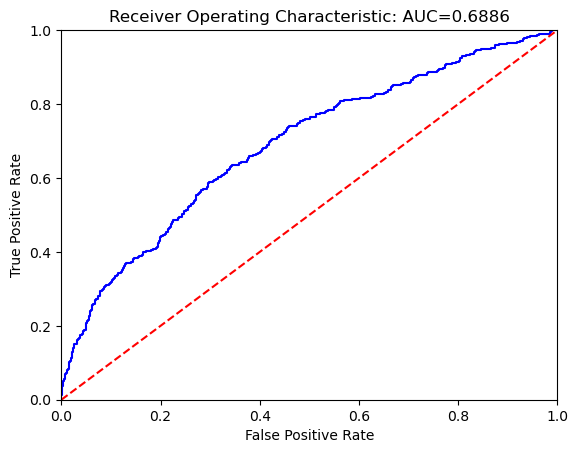

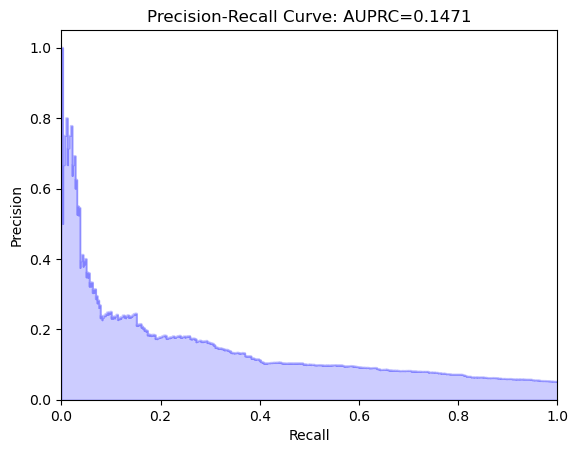

In [17]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
import pickle
with open('task3_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)



RandomForest:
Training time: 6.497102975845337 seconds
AUC: 0.6284675178604455
AUPRC: 0.11832127409750481
Sensitivity: 0.5664556962025317
Specificity: 0.6311586816173972
Score thresold: 0.06
2.5 97.5


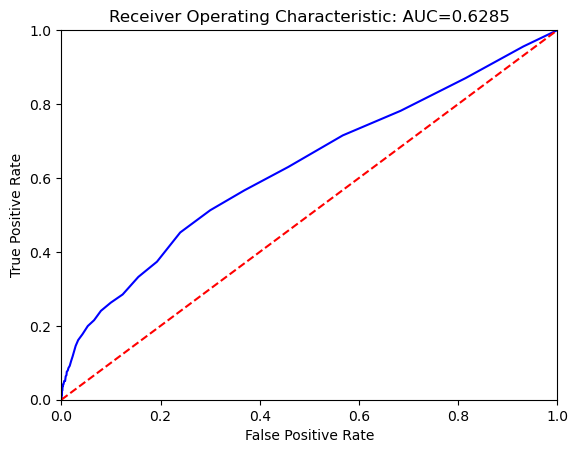

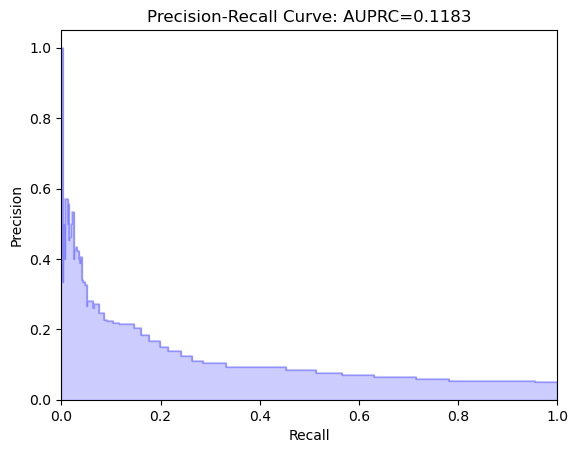

[0.0739325  0.01270184 0.01443589 0.02013679 0.03294808 0.00886705
 0.01286507 0.02305991 0.00216579 0.00405654 0.00743624 0.04029196
 0.02085377 0.00666645 0.00799928 0.00569545 0.00024155 0.0047605
 0.00304085 0.00408241 0.0034996  0.0022978  0.0041727  0.00547997
 0.00603051 0.00543672 0.0054295  0.00209948 0.00906486 0.00336704
 0.00347809 0.00558303 0.00789499 0.00522336 0.00264624 0.00537254
 0.00547932 0.00242404 0.00271735 0.00185743 0.00831209 0.00496695
 0.00428646 0.00554424 0.01059532 0.00645846 0.00631466 0.00224906
 0.00525306 0.00711639 0.00449968 0.00750853 0.00250642 0.00628804
 0.00546244 0.00546842 0.00431477 0.00817431 0.05980445 0.06765197
 0.03424615 0.03798419 0.06846225 0.06676646 0.07072546 0.03816562
 0.05508165]


In [18]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 8.950955867767334 seconds
AUC: 0.6856585783902588
AUPRC: 0.14259202621279166
Sensitivity: 0.6613924050632911
Specificity: 0.6247026843357119
Score thresold: 0.043059379618123936
2.5 97.5


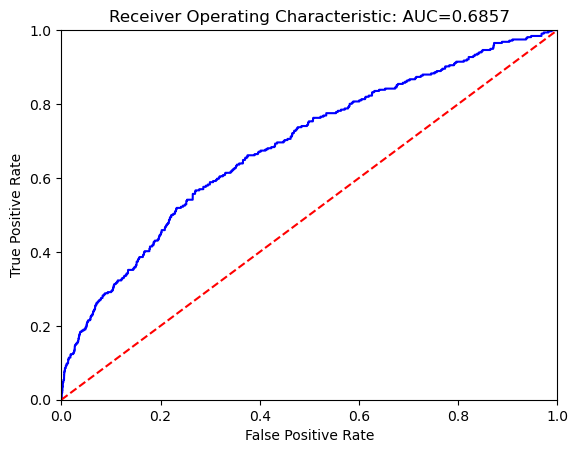

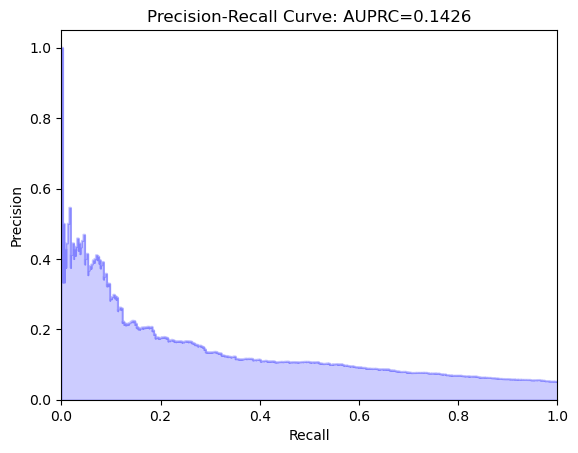

In [26]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [27]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions_task3.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.038819
1,1,0,0.033439
2,2,0,0.032558
3,3,0,0.041476
4,4,0,0.031857


GradientBoosting:
Training time: 8.757960081100464 seconds
AUC: 0.6541492877847187
AUPRC: 0.09452374603201709
Sensitivity: 0.6503496503496503
Specificity: 0.594562243502052
Score thresold: 0.041598295558897116
2.5 97.5


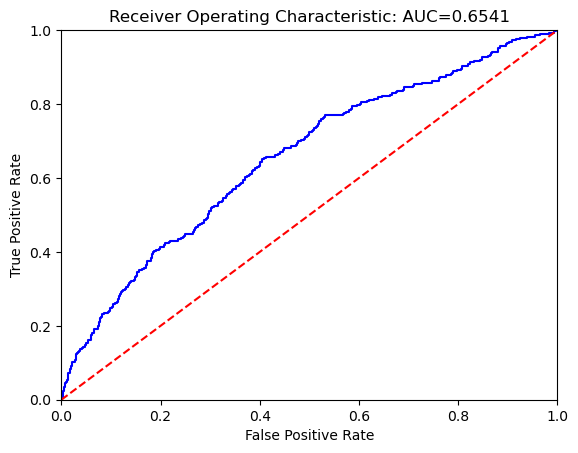

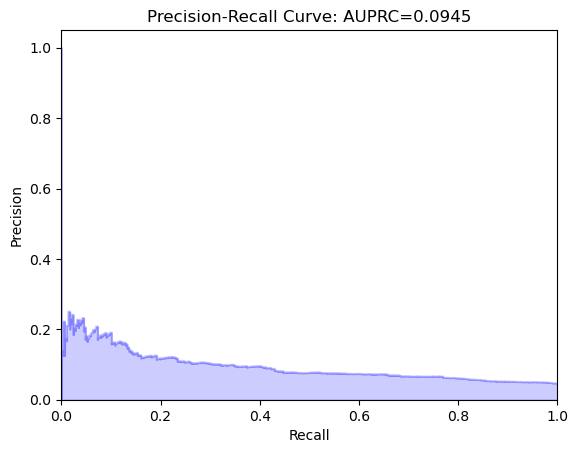

In [28]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [29]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions_task3.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,0,0.038192
1,1,0,0.040124
2,2,0,0.027487
3,3,0,0.077132
4,4,0,0.021838


In [22]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)

2026-03-15 22:43:33.104015: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agc04
2026-03-15 22:43:33.104050: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agc04
2026-03-15 22:43:33.104180: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-03-15 22:43:33.104209: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


Epoch 1/20
246/246 [==============================] - 1s 2ms/step - loss: 0.4872 - accuracy: 0.9395 - auc: 0.5359 - auprc: 0.0594 - tp: 66.0000 - tn: 46149.0000 - precision: 0.0932 - recall: 0.0275
Epoch 2/20
246/246 [==============================] - 0s 1ms/step - loss: 0.1957 - accuracy: 0.9509 - auc: 0.6027 - auprc: 0.0945 - tp: 47.0000 - tn: 46726.0000 - precision: 0.4196 - recall: 0.0196
Epoch 3/20
246/246 [==============================] - 0s 1ms/step - loss: 0.1955 - accuracy: 0.9511 - auc: 0.6052 - auprc: 0.0983 - tp: 50.0000 - tn: 46736.0000 - precision: 0.4762 - recall: 0.0209
Epoch 4/20
246/246 [==============================] - 0s 1ms/step - loss: 0.1911 - accuracy: 0.9513 - auc: 0.6243 - auprc: 0.1042 - tp: 44.0000 - tn: 46748.0000 - precision: 0.5057 - recall: 0.0183
Epoch 5/20
246/246 [==============================] - 0s 1ms/step - loss: 0.1939 - accuracy: 0.9510 - auc: 0.6118 - auprc: 0.1026 - tp: 41.0000 - tn: 46740.0000 - precision: 0.4457 - recall: 0.0171
Epoch 6/20

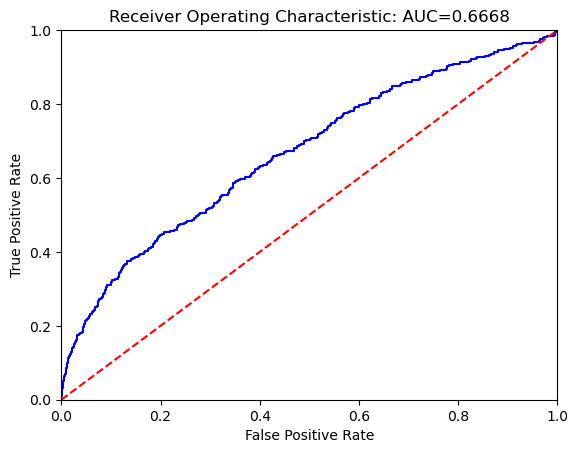

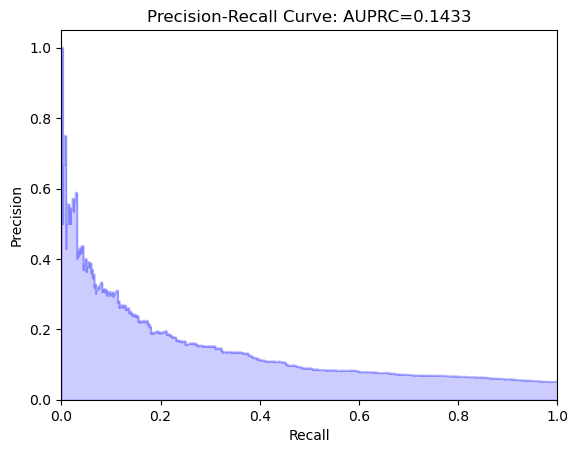

In [23]:
mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('ed_revisit_disposition_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)